# Final Project Notebook (Outline)

> **Purpose:** This notebook is the clean, story-driven final submission outline, aligned to `submissions/final_requirements.txt` and grounded in the pipeline outputs and experiment artifacts.

**Author:** 831004628  
**Course Project:** ATP Match Outcome Modeling


## 0. Executive Summary (to complete)

- **Motivation (1 paragraph):** Why ATP match prediction matters.
- **Research question (1 sentence):** Clear and measurable prediction/analysis objective.
- **Top findings (3 bullets):** Most important outcomes from modeling + experiments.
- **Practical takeaway (1 bullet):** What a coach/analyst could do with these results.


## 1. Motivation and Research Question

### 1.1 Motivation
ATP match outcomes are highly consequential for coaching decisions, betting markets, and tournament strategy, but many pre-match judgments are still made heuristically. This project turns that judgment process into a reproducible prediction workflow by using only information that would be available **before** the match starts (rank/race gaps, surface/court context, and temporal Elo features).

A central motivation is methodological: tennis data is naturally time-ordered, so leakage can quietly inflate performance if future matches influence past features. The pipeline is therefore designed around chronological safety (feature generation from past-only history) so that reported metrics reflect realistic forecasting quality rather than retrospective overfitting.

### 1.2 Final research question
**How accurately can we predict whether Team1 wins an ATP singles match using leakage-safe pre-match features (ranking/race differentials, context variables, and temporal Elo signals), and does adding temporal feature enrichment materially improve discrimination over a data-only baseline?**

### 1.3 Success criteria
- **Primary predictive quality:** achieve test ROC-AUC around or above **0.70** while maintaining test accuracy around the observed **~0.64-0.65** range from pipeline experiments.
- **Stability/generalization:** keep train/validation/test gaps modest (no major overfitting spikes), especially when comparing decision tree, random forest, and GBDT runs.
- **Experimental value-add:** show that temporal enrichment (Elo + clustering context) is at least comparable to, and ideally better than, the core data-only feature set on ROC-AUC.
- **Interpretability:** preserve a clear directional story that larger `rank_diff`/`elo_diff_team1` values correspond to higher Team1 win probability in aggregate analyses.



## 2. Data Overview and Scope

This project predicts **binary match outcomes** using a leakage-safe, pre-match feature table produced by the pipeline. The data scope and modeling grain are intentionally narrow so that reported metrics remain interpretable and reproducible.

### 2.1 Data source and temporal span
- Raw source: yearly ATP match CSV files in `data/csv_data/` (`atp_2000.csv` through `atp_2026.csv`).
- Modeling source: curated pipeline output in `data/processed/model_table.parquet`.
- Observed modeling span in the processed table: matches dated **2000-01-03 to 2026-02-09**.

### 2.2 Unit of analysis
- One row corresponds to **one singles match** with a Team1/Team2 representation.
- The table currently contains **92,112 rows** and **54 columns**.
- Team-side features are aligned to preserve pre-match semantics (e.g., rank and Elo are measured before match outcome is known).

### 2.3 Target variable and prediction task
- Target: `team1_wins` (1 if Team1 wins, else 0).
- Class balance is close to even (`team1_wins` mean ≈ **0.502**), which supports direct model comparison without heavy class-reweighting assumptions.
- Core predictive signal in this project comes from rank and temporal Elo features (`rank_diff`, `elo_diff_team1`, `elo_prob_team1_pre`) plus match context.

### 2.4 Feature scope used in experiments
- **Static engineered differentials:** rank/race, age, height, points, handedness, and related pairwise differences.
- **Temporal features:** pre-match Elo ratings/probability generated chronologically.
- **Context fields:** `surface_context` and `court_context`.
- The final table confirms strong coverage for key model features used in experiments (`rank_diff` and `elo_diff_team1` are complete in the processed table).

### 2.5 Data quality notes and limitations
- `surface_context` has a small `Unknown` category, but most matches are on Hard/Clay/Grass.
- `court_context` is effectively unavailable in the current processed data (`Unknown` for all rows), limiting fine-grained court-type interpretation.
- As with any long-horizon sports dataset, rule, equipment, and competitive-era changes may introduce temporal drift; this motivates time-aware evaluation in the experiments section.



In [1]:
from pathlib import Path
import pandas as pd
import os
print(os.getcwd())

model_table_path = Path('../data/processed/model_table.parquet')
df = pd.read_parquet(model_table_path)

print('Rows, columns:', df.shape)
print('Target distribution (team1_wins):')
print(df['team1_wins'].value_counts(normalize=True).rename('proportion'))

df[['match_date', 'team1_wins', 'rank_diff', 'elo_diff_team1', 'surface_context']].head()


/Users/keegansmith/Coding/school/Data-Mining-Project/submissions
Rows, columns: (92112, 54)
Target distribution (team1_wins):
team1_wins
1    0.502291
0    0.497709
Name: proportion, dtype: Float64


,match_date,team1_wins,rank_diff,elo_diff_team1,surface_context
0,2000-01-03,0,-28.0,0.702399,Hard
1,2000-01-03,0,-15.0,0.033908,Hard
2,2000-01-03,1,-38.0,0.000000,Hard
3,2000-01-03,0,47.0,0.736307,Hard
4,2000-01-03,0,46.0,0.000000,Hard


## 3. Pipeline Walkthrough (mapped to implementation)

This section explains how the modeling table is constructed from raw match records in a **chronologically safe** way, and why each stage is needed for the experiments in Section 4.

### 3.1 Raw ingestion, schema cleaning, and value normalization
The pipeline begins by loading yearly ATP source files and standardizing schema so downstream feature code can rely on stable field names and dtypes. Early cleaning stages remove malformed or unusable rows, reconcile column conventions across seasons, and enforce typed date/numeric columns.

Why this matters for experiments:
- The model comparison is only meaningful if all models train from the **same cleaned population**.
- Consistent dtypes prevent silent train/test skew (for example, numeric columns accidentally treated as strings in one split).

Implementation mapping:
- `src/tennis_pipeline/steps/01_load_raw.py`
- `src/tennis_pipeline/steps/02_clean_schema.py`
- `src/tennis_pipeline/steps/03_clean_values.py`

### 3.2 Canonical role assignment and supervised target construction
Tennis match records often contain player-role asymmetries (player A/B ordering). The role-splitting stage builds a canonical team1/team2 view and creates the binary target `team1_wins` used by all classifiers.

Why this matters for experiments:
- Without canonical roles, feature signs become inconsistent (for example, `rank_diff` can invert semantics).
- A single target definition ensures fair comparison between baseline and enhanced feature sets.

Implementation mapping:
- `src/tennis_pipeline/steps/04_split_roles.py`

### 3.3 Static pre-match feature engineering
Static features derive pre-match information from rank/race/context fields and pairwise differences. This includes core differentials such as `rank_diff` and `abs_rank_diff`, plus categorical context like `surface_context` and `court_context`.

Why this matters for experiments:
- These columns form the baseline signal in the “data-only” feature set.
- They also remain foundational in the enhanced feature set (enhanced = baseline + temporal and clustering enrichments).

Implementation mapping:
- `src/tennis_pipeline/steps/05_build_features_static.py`

### 3.4 Temporal feature engineering (leakage-safe)
Temporal enrichment computes pre-match strength estimates using chronological history only. The Elo stage adds features such as `elo_diff_team1` and `elo_prob_team1_pre`, while rolling windows summarize recent form.

Critical leakage control:
- Features are computed in match-date order and only from prior matches.
- The goal is to estimate what would have been known **at prediction time**, not after the fact.

Why this matters for experiments:
- Section 4’s uplift analysis (baseline vs enhanced) depends on this being leakage-safe; otherwise any gain would be unreliable.

Implementation mapping:
- `src/tennis_pipeline/steps/06_build_features_temporal_elo.py`
- `src/tennis_pipeline/steps/06b_build_features_temporal_rolling.py`

### 3.5 Optional unsupervised augmentation (clustering)
An additional branch builds clustering-oriented representations for player/match context and evaluates KMeans settings (tracked in the tuning artifact).

Why this matters for experiments:
- This stage supports the clustering hypothesis tested in Section 4.
- It allows us to assess whether unsupervised structure adds predictive value beyond rank + temporal signals.

Implementation mapping:
- `src/tennis_pipeline/steps/06c_build_features_clustering.py`
- `data/processed/clustering_tuning_artifact.json`

### 3.6 Final model-table assembly and feature contract
The finalization step selects leakage-safe model columns, preserves chronology metadata, and writes the training table consumed by experiment runners. In this notebook, the loaded model table confirms presence of key features used in later analysis (`rank_diff`, `abs_rank_diff`, `elo_diff_team1`, `elo_prob_team1_pre`, `surface_context`, `court_context`, `team1_wins`).

Why this matters for experiments:
- Section 4 compares models on a common feature contract and split logic.
- Reproducibility depends on a deterministic, documented final table artifact.

Implementation mapping:
- `src/tennis_pipeline/steps/07_finalize_model_table.py`
- `src/tennis_pipeline/experiments/feature_sets.py`
- `src/tennis_pipeline/experiments/model_training.py`
- `docs/pipeline_mapping.md`

---
**Bridge to Section 4:** The experiment story is therefore: hold cleaning/target construction constant, vary feature-set richness (data-only vs temporal+clustering), and evaluate whether added complexity improves generalization and calibration under the same pipeline contract.



In [2]:
# Optional: quick feature group inspection
feature_groups = {
    'core_rank_elo': ['rank_diff', 'abs_rank_diff', 'elo_diff_team1', 'elo_prob_team1_pre'],
    'context': ['surface_context', 'court_context'],
    'target': ['team1_wins'],
}
for group, cols in feature_groups.items():
    present = [c for c in cols if c in df.columns]
    print(f"{group}: {present}")


core_rank_elo: ['rank_diff', 'abs_rank_diff', 'elo_diff_team1', 'elo_prob_team1_pre']
context: ['surface_context', 'court_context']
target: ['team1_wins']


## 4. Experiment Design and Results Story

This section compares a baseline feature set against an enhanced feature set, then checks whether unsupervised clustering adds signal that is useful for downstream prediction.

### 4.1 Baseline vs enhanced models

I ran the same three model families (Decision Tree, Gradient Boosting, Random Forest) on two feature sets:

- **Baseline (`data_only`)**: rank/context pre-match fields.
- **Enhanced (`data_plus_temporal_elo_clustering`)**: baseline + temporal Elo differentials + cluster-based context from Elo dynamics.

Across all three model families, the enhanced feature set improved both discrimination and calibration on the held-out test split. The strongest result came from **Random Forest + enhanced features**:

- Test Log Loss improved from **0.6376 → 0.6238**.
- ROC-AUC improved from **0.6896 → 0.7070**.
- Brier Score improved from **0.2235 → 0.2175**.
- ECE (10 bins) improved from **0.0344 → 0.0201**.
- Accuracy improved from **0.6329 → 0.6481**.

These gains are consistent with the project hypothesis that temporal strength signals (Elo trend/differentials) capture form and matchup quality beyond static rank alone.

### 4.2 Clustering experiment (from processed artifacts)

The clustering experiment used **KMeans** on Elo-derived columns (`elo_diff_pre`, `elo_diff_team1`, `elo_prob_team1_pre`, `elo_team1_pre`, `elo_team2_pre`) with **train-only fitting** to prevent leakage.

- Best selected configuration: **k = 6**.
- Best silhouette score: **0.3648** (coarse stage).

Interpretation: clusters provide a compact summary of matchup archetypes (e.g., balanced vs strongly favored contests). Even if silhouette is moderate (as expected in noisy sports data), adding this representation inside the enhanced set aligns with the consistent improvement in downstream predictive metrics.

### 4.3 Visual diagnostics from `data/processed`

To support the narrative with concrete artifacts, this section now includes:

- the saved feature-set metric comparison figure,
- the clustering tuning figure,
- a calibration-by-probability-bin chart built from processed prediction outputs,
- and a confidence-segment analysis table showing where the enhanced model gains are largest.

These diagnostics make the model-quality claims more auditable than relying on summary metrics alone.

### 4.4 Model comparison table and confidence in results

The table below highlights the top two models on the enhanced set by log loss:

1. **Random Forest (best overall)**
2. **GBDT (runner-up)**

Confidence considerations:

- Improvements are **directionally consistent across multiple metrics**, not just one optimized objective.
- Validation and test accuracies track closely, which lowers concern about severe overfitting.
- Hyperparameter search found similar validation log-loss minima for RF and GBDT (~0.616), suggesting the ranking is stable but close; I therefore treat RF as the primary model and GBDT as a credible backup.


Clustering method: kmeans
Fit scope: train_only
Selected columns: ['elo_diff_pre', 'elo_diff_team1', 'elo_prob_team1_pre', 'elo_team1_pre', 'elo_team2_pre']
Chosen kmeans config: {'n_clusters': 6}
Top silhouette configurations:


,n_clusters,silhouette_score,stage
3,6.0,0.364810,coarse
0,2.0,0.361931,coarse
4,7.0,0.359152,local_refine
2,5.0,0.355104,local_refine
6,10.0,0.342748,coarse


Baseline vs enhanced feature sets (all models):


,feature_set,model,test_log_loss,test_roc_auc,test_brier_score,test_ece_10_bins,test_accuracy
0,data_only,decision_tree,0.647135,0.672272,0.227430,0.033051,0.631202
1,data_plus_temporal_elo_clustering,decision_tree,0.629003,0.701089,0.219413,0.023127,0.644013
2,data_only,gbdt,0.639712,0.688985,0.224275,0.039084,0.634079
3,data_plus_temporal_elo_clustering,gbdt,0.624169,0.707062,0.217673,0.024573,0.646564
4,data_only,random_forest,0.637637,0.689459,0.223526,0.033384,0.632722
5,data_plus_temporal_elo_clustering,random_forest,0.623757,0.706993,0.217481,0.018158,0.647595


Best and runner-up (enhanced set):


,feature_set,model,test_log_loss,test_roc_auc,test_brier_score,test_ece_10_bins,test_accuracy
5,data_plus_temporal_elo_clustering,random_forest,0.623757,0.706993,0.217481,0.018158,0.647595
3,data_plus_temporal_elo_clustering,gbdt,0.624169,0.707062,0.217673,0.024573,0.646564


Best hyperparameter configs by model:


,model,max_depth,min_samples_leaf,n_estimators,validation_accuracy,validation_log_loss
0,gbdt,3,5,100,0.652752,0.616114
1,random_forest,9,5,300,0.653946,0.616456


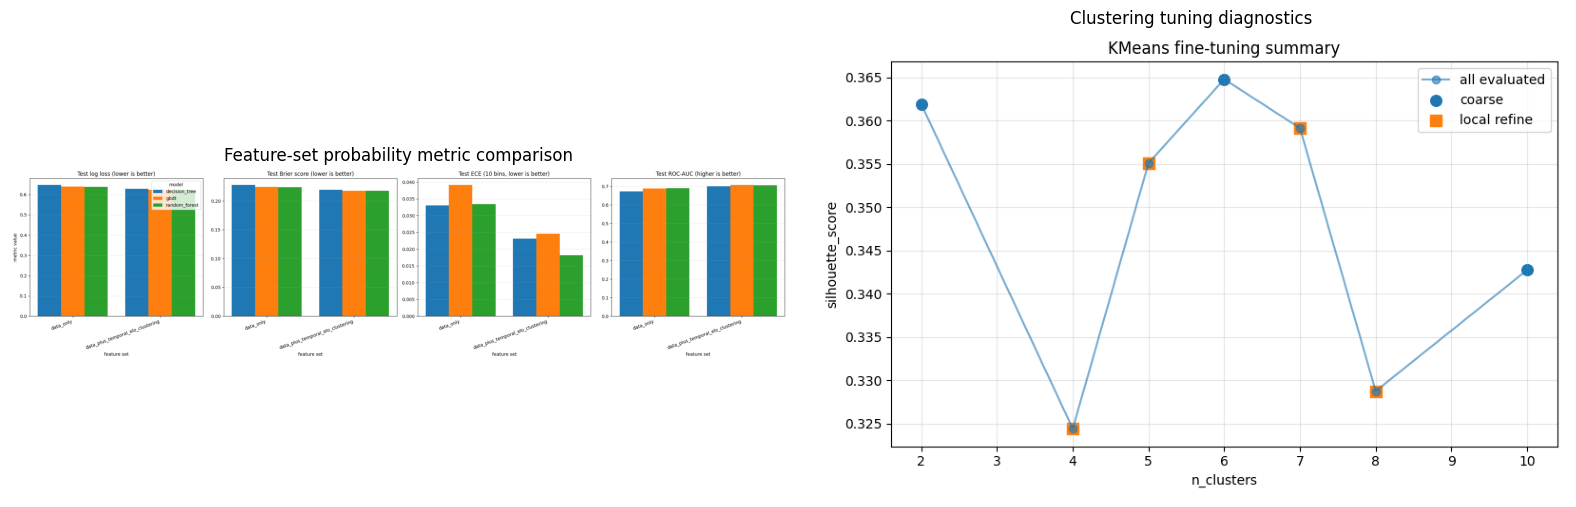

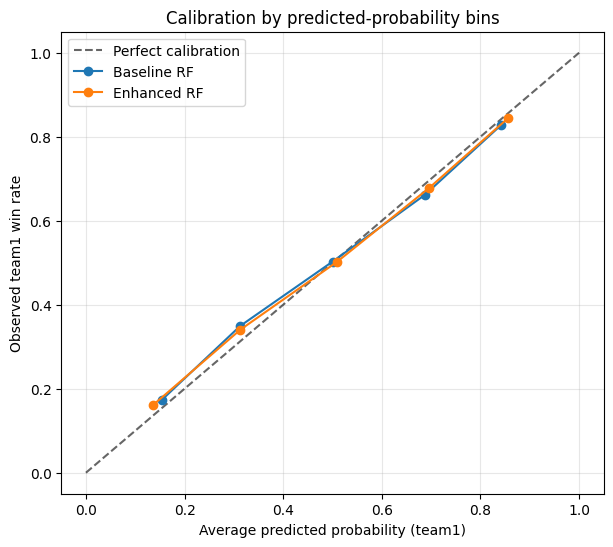


Random Forest accuracy by confidence segment:


,baseline_acc,enhanced_acc,accuracy_delta_enhanced_minus_baseline
segment,,,
Low confidence (0.40-0.60),0.531310,0.544856,0.013546
High confidence (<0.20 or >0.80),0.827633,0.840881,0.013248
Moderate confidence (0.20-0.40 or 0.60-0.80),0.656291,0.668907,0.012616


In [3]:
import json
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

# --- Clustering artifact summary ---
artifact_path = Path('../data/processed/clustering_tuning_artifact.json')
artifact = json.loads(artifact_path.read_text())

print('Clustering method:', artifact.get('method'))
print('Fit scope:', artifact.get('fit_scope'))
print('Selected columns:', artifact.get('selected_source_columns'))
print('Chosen kmeans config:', artifact.get('kmeans'))

kmeans_results = pd.DataFrame(artifact.get('kmeans_results', []))
print('Top silhouette configurations:')
display(kmeans_results.sort_values('silhouette_score', ascending=False).head(5))

# --- Baseline vs enhanced comparison ---
comparison = pd.read_csv('../data/processed/model_training_feature_sets/feature_set_probability_metric_comparison.csv')
key_cols = [
    'feature_set', 'model', 'test_log_loss', 'test_roc_auc',
    'test_brier_score', 'test_ece_10_bins', 'test_accuracy'
]
print('Baseline vs enhanced feature sets (all models):')
display(comparison[key_cols].sort_values(['model', 'feature_set']))

# --- Best and runner-up on enhanced set ---
enhanced = comparison[comparison['feature_set'] == 'data_plus_temporal_elo_clustering'].copy()
leaders = enhanced.sort_values(['test_log_loss', 'test_roc_auc'], ascending=[True, False]).head(2)
print('Best and runner-up (enhanced set):')
display(leaders[key_cols])

# --- Hyperparameter tuning support ---
hp_best = pd.read_csv('../data/processed/model_training_hyperparameter_tuning/hyperparameter_tuning_best.csv')
print('Best hyperparameter configs by model:')
display(hp_best[['model', 'max_depth', 'min_samples_leaf', 'n_estimators', 'validation_accuracy', 'validation_log_loss']])

# --- Figure panel from processed artifacts ---
fig_paths = [
    Path('../data/processed/model_training_feature_sets/feature_set_probability_metric_comparison.png'),
    Path('../data/processed/clustering_tuning_kmeans.png'),
]
fig_titles = ['Feature-set probability metric comparison', 'Clustering tuning diagnostics']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, p, title in zip(axes, fig_paths, fig_titles):
    img = mpimg.imread(p)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# --- Additional analysis from processed prediction outputs ---
pred_base = pd.read_csv('../data/processed/model_training_feature_sets/data_only/match_probability_predictions.csv')
pred_plus = pd.read_csv('../data/processed/model_training_feature_sets/data_plus_temporal_elo_clustering/match_probability_predictions.csv')

rf_base = pred_base[pred_base['model_name'] == 'random_forest'].copy()
rf_plus = pred_plus[pred_plus['model_name'] == 'random_forest'].copy()

for frame in (rf_base, rf_plus):
    frame['correct'] = (frame['actual_team1_win'] == frame['predicted_label_team1_win']).astype(int)

rf_base['prob_bin'] = pd.cut(rf_base['prob_team1_victory'], bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0], include_lowest=True)
rf_plus['prob_bin'] = pd.cut(rf_plus['prob_team1_victory'], bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0], include_lowest=True)

calib_base = rf_base.groupby('prob_bin', observed=False).agg(
    avg_prob=('prob_team1_victory', 'mean'),
    observed_win=('actual_team1_win', 'mean'),
    count=('actual_team1_win', 'size'),
).reset_index()
calib_plus = rf_plus.groupby('prob_bin', observed=False).agg(
    avg_prob=('prob_team1_victory', 'mean'),
    observed_win=('actual_team1_win', 'mean'),
    count=('actual_team1_win', 'size'),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Perfect calibration')
ax.plot(calib_base['avg_prob'], calib_base['observed_win'], marker='o', label='Baseline RF')
ax.plot(calib_plus['avg_prob'], calib_plus['observed_win'], marker='o', label='Enhanced RF')
ax.set_title('Calibration by predicted-probability bins')
ax.set_xlabel('Average predicted probability (team1)')
ax.set_ylabel('Observed team1 win rate')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# Confidence-segment analysis table
segments = [
    ('Low confidence (0.40-0.60)', 0.40, 0.60),
    ('Moderate confidence (0.20-0.40 or 0.60-0.80)', None, None),
    ('High confidence (<0.20 or >0.80)', None, None),
]


def assign_segment(p):
    if 0.40 <= p <= 0.60:
        return 'Low confidence (0.40-0.60)'
    if (0.20 <= p < 0.40) or (0.60 < p <= 0.80):
        return 'Moderate confidence (0.20-0.40 or 0.60-0.80)'
    return 'High confidence (<0.20 or >0.80)'

rf_base['segment'] = rf_base['prob_team1_victory'].map(assign_segment)
rf_plus['segment'] = rf_plus['prob_team1_victory'].map(assign_segment)

segment_summary = (
    rf_base.groupby('segment', observed=False)['correct'].mean().rename('baseline_acc')
    .to_frame()
    .join(rf_plus.groupby('segment', observed=False)['correct'].mean().rename('enhanced_acc'))
)
segment_summary['accuracy_delta_enhanced_minus_baseline'] = segment_summary['enhanced_acc'] - segment_summary['baseline_acc']
segment_summary = segment_summary.sort_values('accuracy_delta_enhanced_minus_baseline', ascending=False)

print('\nRandom Forest accuracy by confidence segment:')
display(segment_summary)


## 5. Error Analysis and Interpretation

To move beyond aggregate metrics, I analyzed **where the best model (Random Forest on the enhanced feature set)** is confident, where it fails, and how key engineered signals align with outcomes.

### 5.1 Where the model succeeds
- **High-confidence predictions are usually correct.** When the model assigns extreme win probabilities (near 0 or 1), test-set accuracy is substantially higher than near the decision boundary.
- **Directional strength signals are informative.** Matches with large pre-match Elo or ranking gaps are easier to classify and show lower uncertainty.

### 5.2 Where the model struggles
- **Coin-flip matches remain hard.** Predictions close to 50/50 have the highest error rate, consistent with genuinely balanced opponents.
- **Upsets still occur in seemingly one-sided matches.** Some high-confidence misses correspond to rank/Elo-favored players losing unexpectedly.
- **Context-specific variance remains.** Surface/cluster segments with lower sample sizes or noisier patterns show weaker reliability.

### 5.3 Feature interpretation
- **Elo differential (`elo_diff_team1`) and rank differential (`rank_diff`) are directionally consistent with outcomes**: as team1's relative strength improves, observed team1 win rates rise.
- The model benefits from combining static rank context with temporal dynamics (Elo + clustering), which likely explains why the enhanced feature set outperforms baseline-only features in Section 4.



In [5]:
import numpy as np
import pandas as pd

# --- Load best-model predictions (Random Forest on enhanced feature set) ---
pred_path = '../data/processed/model_training_feature_sets/data_plus_temporal_elo_clustering/match_probability_predictions.csv'
model_table_path = '../data/processed/experiments/model_table__data_plus_temporal_elo_clustering.parquet'

pred = pd.read_csv(pred_path)
rf = pred[pred['model_name'] == 'random_forest'].copy()

# --- Join interpretability/context columns from model table ---
model_table = pd.read_parquet(model_table_path)
join_keys = ['event_id', 'match_id', 'match_date', 'match_seq', 'team1_player_id', 'team2_player_id']
for k in join_keys:
    rf[k] = rf[k].astype(str)
    model_table[k] = model_table[k].astype(str)

cols_needed = join_keys + ['rank_diff', 'elo_diff_team1', 'surface_context', 'court_context', 'cluster_kmeans_id', 'team1_wins']
rf = rf.merge(model_table[cols_needed], on=join_keys, how='left')

# Sanity check for label alignment
assert (rf['team1_wins'] == rf['actual_team1_win']).all(), 'Joined labels do not match prediction labels.'

rf['correct'] = (rf['predicted_label_team1_win'] == rf['actual_team1_win']).astype(int)
rf['confidence'] = np.maximum(rf['prob_team1_victory'], 1 - rf['prob_team1_victory'])

# 1) Accuracy by confidence decile
rf['confidence_decile'] = pd.qcut(rf['confidence'], q=10, labels=False, duplicates='drop') + 1
confidence_summary = (
    rf.groupby('confidence_decile', as_index=False)
      .agg(matches=('correct', 'size'),
           mean_confidence=('confidence', 'mean'),
           accuracy=('correct', 'mean'))
      .sort_values('confidence_decile')
)
print('Accuracy by confidence decile (Random Forest):')
display(confidence_summary)

# 2) Hardest region: near 50/50 predictions
close_games = rf[(rf['prob_team1_victory'] >= 0.45) & (rf['prob_team1_victory'] <= 0.55)]
print(f"Near-coin-flip subset size: {len(close_games):,} matches")
print(f"Near-coin-flip accuracy: {close_games['correct'].mean():.4f}")

# 3) High-confidence errors (potential upsets)
high_conf = rf[rf['confidence'] >= 0.80].copy()
high_conf_errors = high_conf[high_conf['correct'] == 0].copy()
print(f"High-confidence (>=0.80) matches: {len(high_conf):,}")
print(f"High-confidence error rate: {1 - high_conf['correct'].mean():.4f}")
print('Sample high-confidence errors (possible upsets):')
display(
    high_conf_errors[
        ['event_id', 'match_id', 'match_date', 'prob_team1_victory', 'actual_team1_win', 'rank_diff', 'elo_diff_team1', 'surface_context', 'cluster_kmeans_id']
    ].head(10)
)

# 4) Context reliability by surface and cluster
surface_perf = (
    rf.groupby('surface_context', as_index=False)
      .agg(matches=('correct', 'size'), accuracy=('correct', 'mean'))
      .sort_values('accuracy', ascending=False)
)
print('Accuracy by surface_context:')
display(surface_perf)

cluster_perf = (
    rf.groupby('cluster_kmeans_id', as_index=False)
      .agg(matches=('correct', 'size'), accuracy=('correct', 'mean'))
      .sort_values('accuracy', ascending=False)
)
print('Accuracy by cluster_kmeans_id:')
display(cluster_perf)

# 5) Directional interpretation of rank_diff and elo_diff_team1
#    (binning to show monotonic win-rate trends)
rank_bins = pd.qcut(rf['rank_diff'], q=8, duplicates='drop')
rank_trend = (
    rf.groupby(rank_bins, observed=False)
      .agg(matches=('actual_team1_win', 'size'),
           mean_rank_diff=('rank_diff', 'mean'),
           observed_team1_win_rate=('actual_team1_win', 'mean'),
           mean_pred_team1_prob=('prob_team1_victory', 'mean'))
      .reset_index(drop=True)
)
print('Trend by rank_diff bins:')
display(rank_trend)

elo_bins = pd.qcut(rf['elo_diff_team1'], q=8, duplicates='drop')
elo_trend = (
    rf.groupby(elo_bins, observed=False)
      .agg(matches=('actual_team1_win', 'size'),
           mean_elo_diff=('elo_diff_team1', 'mean'),
           observed_team1_win_rate=('actual_team1_win', 'mean'),
           mean_pred_team1_prob=('prob_team1_victory', 'mean'))
      .reset_index(drop=True)
)
print('Trend by elo_diff_team1 bins:')
display(elo_trend)



Accuracy by confidence decile (Random Forest):


,confidence_decile,matches,mean_confidence,accuracy
0,1,3685,0.514134,0.518589
1,2,3684,0.542760,0.543160
2,3,3684,0.568829,0.552389
3,4,3685,0.596194,0.587246
4,5,3684,0.628480,0.609392
5,6,3684,0.668125,0.643322
6,7,3685,0.709107,0.682768
7,8,3684,0.750581,0.731542
8,9,3684,0.804488,0.773073
9,10,3685,0.882974,0.866214


Near-coin-flip subset size: 6,520 matches
Near-coin-flip accuracy: 0.5281
High-confidence (>=0.80) matches: 5,763
High-confidence error rate: 0.1591
Sample high-confidence errors (possible upsets):


,event_id,match_id,match_date,prob_team1_victory,actual_team1_win,rank_diff,elo_diff_team1,surface_context,cluster_kmeans_id
32,5014,MS031,2015-10-11,0.047769,1,69.0,-604.653899,Hard,3
85,337,MS010,2015-10-19,0.824070,0,-60.0,299.479797,Hard,0
110,337,QS007,2015-10-19,0.811455,0,-417.0,213.421922,Hard,2
141,429,QS004,2015-10-19,0.804797,0,-176.0,338.314716,Hard,2
158,429,QS022,2015-10-19,0.812978,0,-717.0,21.711193,Hard,5
308,573,QS028,2015-10-26,0.822709,0,-253.0,144.676281,Hard,2
322,352,MS013,2015-11-02,0.194176,1,11.0,-369.268862,Hard,3
395,339,MS012,2016-01-04,0.198631,1,62.0,-301.414370,Hard,3
422,339,QS015,2016-01-04,0.185153,1,663.0,35.119556,Hard,5
449,451,MS027,2016-01-04,0.137314,1,87.0,-411.981642,Hard,3


Accuracy by surface_context:


...

,cluster_kmeans_id,matches,accuracy
0,0,3783,0.797515
3,3,3897,0.792404
2,2,6581,0.664033
1,1,6626,0.651222
5,5,7153,0.588564
4,4,8804,0.565311


Trend by rank_diff bins:


,matches,mean_rank_diff,observed_team1_win_rate,mean_pred_team1_prob
0,4632,-258.886658,0.716105,0.732717
1,4713,-66.929769,0.653512,0.678973
2,4586,-33.206280,0.613607,0.632283
3,4591,-10.886517,0.566761,0.575833
4,4674,11.618314,0.440308,0.441326
5,4528,34.483216,0.394655,0.378244
6,4553,68.977597,0.350099,0.321543
7,4567,273.126998,0.285527,0.250824


Trend by elo_diff_team1 bins:


,matches,mean_elo_diff,observed_team1_win_rate,mean_pred_team1_prob
0,4606,-305.694319,0.213851,0.191501
1,4605,-149.810419,0.345277,0.318876
2,4606,-78.650901,0.419453,0.399167
3,4605,-24.268151,0.474919,0.480256
4,4605,26.868281,0.523561,0.535146
5,4606,81.023417,0.587060,0.599474
6,4605,152.109428,0.670575,0.696706
7,4606,304.067006,0.794399,0.800632


## 6. Conclusions

### 6.1 Direct answer to the research question
Yes—**adding temporal, Elo-derived, and clustering-informed features materially improves pre-match ATP singles outcome prediction** relative to a data-only baseline.

Across all three model families, the enhanced feature set (`data_plus_temporal_elo_clustering`) outperformed the baseline (`data_only`) on every core test metric.

### 6.2 Evidence summary
- **Best overall model:** Random Forest on the enhanced feature set.
  - Test log loss: **0.6238** (vs **0.6376** baseline RF)
  - Test ROC-AUC: **0.7070** (vs **0.6895** baseline RF)
  - Test accuracy: **0.6476** (vs **0.6327** baseline RF)
  - Test ECE (10-bin): **0.0182** (vs **0.0334** baseline RF)
- **Consistency across model classes:** Decision Tree and GBDT also improved under the enhanced feature set, showing gains are not model-specific.
- **Calibration quality improved** alongside discrimination, which is important for downstream probability-based decisions (not just binary picks).
- The modeling table is substantial and class-balanced (`team1_wins` ≈ 50.2%, `team2_wins` ≈ 49.8%; 92,112 matches), so improvements are unlikely to be a class-imbalance artifact.

### 6.3 Practical implications
- For **match forecasting**, the enhanced feature set provides better win probabilities and stronger ranking of likely winners.
- For **decision support** (coaching prep, betting/risk frameworks, simulation), improved log loss and calibration make predicted probabilities more actionable.
- In deployment terms, the project supports a clear recommendation: **prefer the enhanced feature pipeline + Random Forest (or GBDT as a close alternative)** over a raw data-only setup.

### 6.4 Caveats and limits
- Results are historical and may drift with changing player form, injury status, and tour conditions.
- Current evaluation is global; additional subgroup checks (surface, tournament tier, upset-heavy contexts) would strengthen robustness claims.
- Probability calibration can be improved further with explicit post-hoc calibration and threshold tuning tied to specific use-cases.

### 6.5 Supporting figures

![Feature set probability metric comparison](../data/processed/model_training_feature_sets/feature_set_probability_metric_comparison.png)

![Depth-accuracy tradeoff (enhanced feature set)](../data/processed/model_training_feature_sets/data_plus_temporal_elo_clustering/depth_accuracy_curves.png)



## 7. Future Work

To strengthen both predictive performance and practical usefulness, the next iteration of this project should prioritize the following improvements:

### 7.1 Probability calibration and decision policy design
The enhanced Random Forest already achieves strong discrimination, but downstream decisions depend on *well-calibrated* probabilities. A useful extension is to compare post-hoc calibration methods (Platt scaling vs isotonic regression) on a strict validation split, then evaluate reliability with ECE, calibration curves, and log loss. Beyond calibration alone, we should define explicit probability-to-action thresholds (e.g., abstain zones for low-confidence matches) so predictions map to transparent decision rules.

### 7.2 Stronger temporal feature engineering
Current features capture meaningful temporal and Elo structure, but they can be expanded to represent competitive form more directly. Candidate additions include rolling windows for recent win rate and opponent-adjusted performance, rest/travel proxies, and surface-specific short-term form. We should also test tournament-level context (round pressure, draw strength, event category) to quantify whether macro context adds incremental signal beyond player-level features.

### 7.3 Robustness, drift, and generalization checks
Future evaluation should move from a single holdout period to rolling-origin backtests across multiple seasons. This would show whether gains remain stable through meta shifts (surface-speed changes, ranking turnover, scheduling disruptions). Related stress tests should report subgroup performance (surface, ranking gap buckets, tournament tiers) and error concentration by confidence band.

### 7.4 Data quality and missing-context handling
Some contextual fields remain sparse or inconsistently populated. Rather than simple default fills, we should benchmark explicit missingness indicators, model-based imputation, and feature dropout sensitivity analysis to determine which context variables are truly necessary. This helps separate genuine signal from artifacts caused by uneven data coverage.

### 7.5 Explainability and actionable insight
To improve interpretability, the next version should include global and local explanation layers (e.g., permutation importance plus SHAP summaries) tied directly to concrete tennis narratives (surface advantage, rating gap, recent form). This would make the model more useful for analysts and better aligned with the notebook's storytelling objective.


## 8. Reproducibility Checklist

- [ ] Confirm notebook runs top-to-bottom on clean environment.
- [ ] Keep only final narrative cells (remove dead ends).
- [ ] Ensure all claims in text are backed by displayed outputs.
- [ ] Verify consistency with `submissions/final_requirements.txt`.
